# MLP Regressor para previsão do preço de fechamento do Bitcoin

## Base de dados

Base: `bitcoin.xlsx`

Série diária do mercado de Bitcoin. O alvo é o preço de fechamento `priceClose` do dia seguinte.

- **Granularidade:** diária
- **Random state:** 42
- **Divisão temporal:** 70% inicial para treino e 30% final para teste

## Importações e configurações


In [1]:
from copy import deepcopy
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import sys

PROJECT_ROOT = next(
    (pasta for pasta in (Path.cwd(), *Path.cwd().parents)
     if (pasta / 'validacao_bases.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Não foi possível localizar validacao_bases.py a partir do diretório atual.'
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from funcoes_series_temporais import (
    analisar_componente_residual, calcular_forca_sazonalidade,
    calcular_importancia_features,
)

In [2]:
BASE_NAME = 'bitcoin'
SEED = 42
HORIZON = 1
SEASONAL_PERIOD = 7
SEASONAL_NAME = 'semanal'
PERIOD_LABEL = 'dia'
PERIOD_LABEL_PLURAL = 'dias'
TARGET_UNIT = 'unidade monetária'
VISUAL_RESAMPLE = 'W'
VISUAL_LABEL = 'médias semanais'
MIN_VALIDATION_SAMPLES = 90
LJUNG_LAGS = [1, 2, 3, 7, 14, 28]
MAX_ACF_LAG = 28
print(f"Base: {BASE_NAME}")

Base: bitcoin


## Configuração do MLP Regressor


In [3]:
# Configuração causal compartilhada para a base selecionada.
from features_temporais import configuracao_features

FEATURE_CONFIG = configuracao_features(BASE_NAME)
TARGET_LAGS = list(FEATURE_CONFIG.lags_alvo)
EXOG_LAGS = {coluna: list(lags) for coluna, lags in FEATURE_CONFIG.lags_exogenas.items()}
EXOG_COLUMNS = list(EXOG_LAGS)
ROLLING_WINDOWS = list(FEATURE_CONFIG.janelas_moveis)
CALENDAR_COMPONENTS = list(FEATURE_CONFIG.calendario)
KNOWN_INDICATORS = dict(FEATURE_CONFIG.indicadores_conhecidos)
SCALER = 'standard'
VALIDATION_RATIO = 0.15
PATIENCE = 20
MIN_DELTA = 1e-4
BATCH_SIZE = 128
N_SPLITS_VALIDACAO = 3
MESES_VALIDACAO = 6
MAX_AMOSTRA_MAE_TREINO = 5000
CANDIDATOS_MLP = [
    {'nome': 'simples_32_relu_adam', 'hidden_layer_sizes': (32,), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-4, 'max_iter': 100},
    {'nome': 'media_64_relu_adam', 'hidden_layer_sizes': (64,), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-3, 'max_iter': 120},
    {'nome': 'aula_64x64_relu_adam', 'hidden_layer_sizes': (64, 64), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-4, 'max_iter': 100},
    {'nome': 'simples_32_tanh_adam', 'hidden_layer_sizes': (32,), 'activation': 'tanh', 'solver': 'adam', 'alpha': 1e-3, 'max_iter': 100},
    {'nome': 'simples_32_relu_sgd', 'hidden_layer_sizes': (32,), 'activation': 'relu', 'solver': 'sgd', 'alpha': 1e-4, 'max_iter': 120},
]

# 1. Preparação da base


## Base tratada

- **Objetivo:** carregar a série regularizada e preservar o corte cronológico entre treino e teste.
- **Importância:** todos os modelos da base partem da mesma amostra, permitindo uma comparação justa.
- **Cuidado:** os lags são calculados antes da remoção das linhas incompletas para manter o alinhamento temporal.

In [4]:
# Carrega a base tratada e verifica sua integridade.
from preparacao_bases import carregar_base_tratada

df, metadados_base = carregar_base_tratada(BASE_NAME, PROJECT_ROOT)
TARGET_COLUMN = metadados_base['alvo']
FREQUENCY = metadados_base['frequencia']
TRAIN_RATIO = metadados_base['treino']
SEED = metadados_base['seed']
FIM_TREINO = pd.Timestamp(metadados_base['fim_treino'])
INICIO_TESTE = pd.Timestamp(metadados_base['inicio_teste'])
np.random.seed(SEED)
diagnostico_base = pd.DataFrame([{
    'base': BASE_NAME, 'linhas': len(df), 'alvos_ausentes': int(df[TARGET_COLUMN].isna().sum()),
    'fim_treino': FIM_TREINO, 'inicio_teste': INICIO_TESTE, 'seed': SEED,
}])
display(diagnostico_base)

,base,linhas,alvos_ausentes,fim_treino,inicio_teste,seed
0,bitcoin,2945,23,2024-04-12 12:00:00,2024-04-13 12:00:00,42


## Dicionário de dados

- **Alvo:** preço de fechamento `priceClose`.
- **Entradas:** abertura, máxima, mínima e volume, sempre defasados.
- **Importância:** registrar quando cada variável está disponível evita utilizar informações futuras na previsão.

In [5]:
# Registra o papel e a disponibilidade temporal das variáveis.
colunas_dicionario = [TARGET_COLUMN, *EXOG_COLUMNS, *KNOWN_INDICATORS]
dicionario = pd.DataFrame([
    {
        'variavel': coluna,
        'papel': (
            'alvo' if coluna == TARGET_COLUMN
            else 'indicador conhecido' if coluna in KNOWN_INDICATORS
            else 'exogena defasada'
        ),
        'tipo': str(df[coluna].dtype),
        'uso_no_modelo': (
            'valor do período conhecido antecipadamente'
            if coluna in KNOWN_INDICATORS else 'somente valores de períodos anteriores'
        ),
    }
    for coluna in colunas_dicionario
]).set_index('variavel')
display(dicionario)

,papel,tipo,uso_no_modelo
variavel,,,
priceClose,alvo,float64,somente valores de períodos anteriores
priceOpen,exogena defasada,float64,somente valores de períodos anteriores
priceHigh,exogena defasada,float64,somente valores de períodos anteriores
priceLow,exogena defasada,float64,somente valores de períodos anteriores
volume,exogena defasada,float64,somente valores de períodos anteriores


## Análise exploratória

A exploração verifica:

- distribuição e evolução temporal das variáveis;
- valores ausentes e possíveis outliers pelo intervalo interquartil;
- padrões que podem orientar lags e janelas móveis.

> Os outliers são sinalizados, mas não removidos automaticamente, pois valores extremos podem ser observações reais.

,n,ausentes,media,desvio_padrao,minimo,q1,mediana,q3,maximo,limite_iqr_inferior,limite_iqr_superior,sinais_outlier_iqr,percentual_outlier_iqr
variavel,,,,,,,,,,,,,
priceClose,2922,23,4.264995e+04,3.253724e+04,3.236762e+03,1.132244e+04,3.550612e+04,6.489856e+04,1.247525e+05,-6.904174e+04,1.452627e+05,0,0.000
priceOpen,2927,18,4.261180e+04,3.251397e+04,3.236275e+03,1.132235e+04,3.538403e+04,6.484168e+04,1.247521e+05,-6.895666e+04,1.451207e+05,0,0.000
priceHigh,2927,18,4.342520e+04,3.302468e+04,3.275378e+03,1.153502e+04,3.643331e+04,6.602157e+04,1.261981e+05,-7.019481e+04,1.477514e+05,0,0.000
priceLow,2927,18,4.174889e+04,3.196118e+04,3.191304e+03,1.101527e+04,3.390208e+04,6.366692e+04,1.231960e+05,-6.796220e+04,1.426444e+05,0,0.000
volume,2927,18,3.254352e+10,2.136083e+10,3.064030e+09,1.810125e+10,2.857563e+10,4.156891e+10,3.509679e+11,-1.710023e+10,7.677039e+10,107,0.037


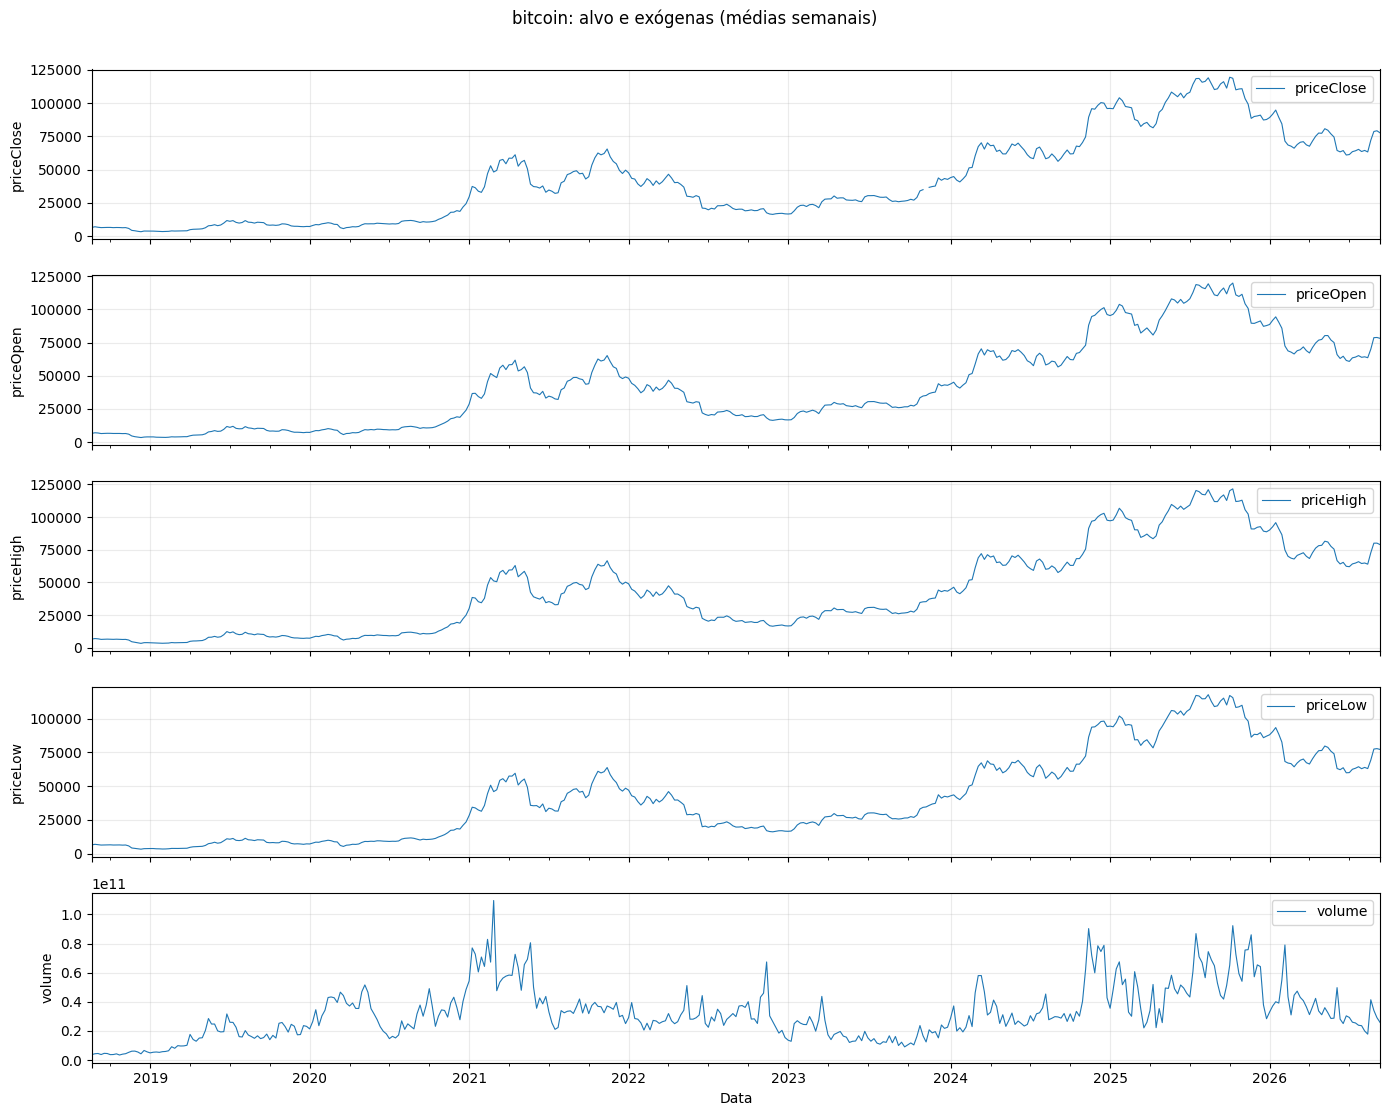

Decisão: preservar valores extremos plausíveis; não aplicar clipping global.
O alvo não é imputado; exógenas usam forward-fill causal limitado a 1 período(s).


In [6]:
# Diagnóstico visual e sinais de outlier, sem remoção automática.
def diagnosticar_exploracao(dados, colunas, fator_iqr=1.5):
    faltantes = [coluna for coluna in colunas if coluna not in dados.columns]
    if faltantes:
        raise KeyError(f'Colunas ausentes na base: {faltantes}')
    linhas = []
    for coluna in colunas:
        serie = pd.to_numeric(dados[coluna], errors='coerce')
        validos = serie.dropna()
        q1, q3 = validos.quantile([0.25, 0.75])
        iqr = q3 - q1
        inferior, superior = q1 - fator_iqr * iqr, q3 + fator_iqr * iqr
        outliers = ((validos < inferior) | (validos > superior)).sum()
        linhas.append({
            'variavel': coluna, 'n': int(validos.size),
            'ausentes': int(serie.isna().sum()), 'media': float(validos.mean()),
            'desvio_padrao': float(validos.std()), 'minimo': float(validos.min()),
            'q1': float(q1), 'mediana': float(validos.median()), 'q3': float(q3),
            'maximo': float(validos.max()), 'limite_iqr_inferior': float(inferior),
            'limite_iqr_superior': float(superior), 'sinais_outlier_iqr': int(outliers),
            'percentual_outlier_iqr': float(outliers / max(1, validos.size)),
        })
    return pd.DataFrame(linhas).set_index('variavel')

colunas_exploracao = [TARGET_COLUMN] + EXOG_COLUMNS
resumo_exploracao = diagnosticar_exploracao(df, colunas_exploracao)
display(resumo_exploracao.round(3))

fig, axes = plt.subplots(
    len(colunas_exploracao), 1,
    figsize=(14, max(8, 2.2 * len(colunas_exploracao))), sharex=True,
)
axes = np.atleast_1d(axes)
for ax, coluna in zip(axes, colunas_exploracao):
    df[coluna].resample(VISUAL_RESAMPLE).mean().plot(ax=ax, linewidth=0.8, label=coluna)
    ax.set_ylabel(coluna)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('Data')
fig.suptitle(f'{BASE_NAME}: alvo e exógenas ({VISUAL_LABEL})', y=1.01)
plt.tight_layout()
plt.show()

print('Decisão: preservar valores extremos plausíveis; não aplicar clipping global.')
print(
    'O alvo não é imputado; exógenas usam forward-fill causal limitado a '
    f"{metadados_base['limite_ffill']} período(s)."
)

# 2. Sazonalidade


## Decomposição STL

A STL separa a série de treino em três componentes:

- **tendência:** movimento de longo prazo;
- **sazonalidade:** padrão semanal recorrente;
- **resíduo:** variação não explicada pelos dois componentes anteriores.

Essa separação confirma se o ciclo de 7 dias usado nas features está presente na série.

STL no treino: 2018-08-22 12:00:00 a 2023-09-17 12:00:00 (1,853 dias)
Força sazonal semanal: 0.0000
Força de tendência: 0.9933


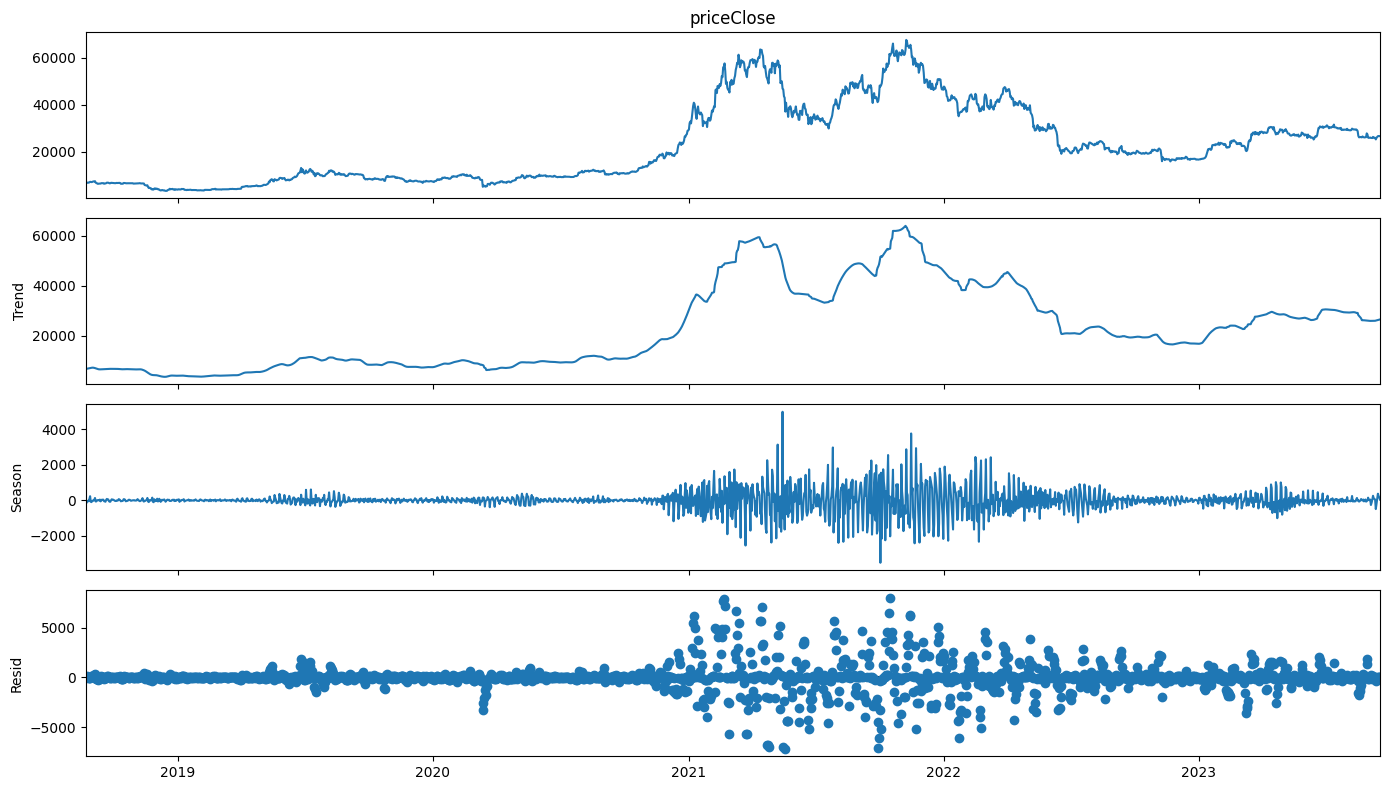

In [7]:
# Seleciona o maior trecho contínuo para a decomposição.
def maior_trecho_continuo(serie):
    observada = serie.dropna().sort_index()
    passo = pd.date_range('2000-01-01', periods=2, freq=FREQUENCY).to_series().diff().iloc[-1]
    blocos = observada.index.to_series().diff().ne(passo).cumsum()
    grupos = list(observada.groupby(blocos.to_numpy()))
    return max(grupos, key=lambda par: len(par[1]))[1].asfreq(FREQUENCY)

serie_stl = maior_trecho_continuo(df.loc[df.index < INICIO_TESTE, TARGET_COLUMN])
assert serie_stl.notna().all()
print(
    f'STL no treino: {serie_stl.index.min()} a {serie_stl.index.max()} '
    f'({len(serie_stl):,} {PERIOD_LABEL_PLURAL})'
)
stl_resultado = calcular_forca_sazonalidade(serie_stl, periodo=SEASONAL_PERIOD)
decomposicao = stl_resultado['decomposicao']
print(f"Força sazonal {SEASONAL_NAME}: {stl_resultado['forca_sazonalidade']:.4f}")
print(f"Força de tendência: {stl_resultado['forca_tendencia']:.4f}")
fig = decomposicao.plot(); fig.set_size_inches(14, 8)
plt.tight_layout(); plt.show()

## Força da sazonalidade e resíduos

- **Força sazonal:** quantifica quanto da variação é explicada pelo ciclo semanal.
- **Força da tendência:** indica a relevância das mudanças de longo prazo.
- **Resíduos:** devem apresentar média próxima de zero e pouca estrutura temporal.

A autocorrelação residual sugere quais dependências ainda podem não ter sido capturadas.

In [8]:
# Analisa a sazonalidade e os resíduos da decomposição.
analise_residuos_stl = analisar_componente_residual(
    decomposicao, lags=SEASONAL_PERIOD
)
print(f"Média do residual: {analise_residuos_stl['media']:.6f}")
print(f"Desvio-padrão do residual: {analise_residuos_stl['desvio_padrao']:.6f}")
display(analise_residuos_stl['autocorrelacao_residual'])

Média do residual: 9.437960
Desvio-padrão do residual: 1335.653935


,lb_stat,lb_pvalue
1,722.539106,3.754369e-159
2,1079.592563,3.710681e-235
3,1209.293777,7.059231e-262
4,1243.998770,4.608789e-268
5,1245.173988,4.815195e-267
6,1257.425671,1.781317e-268
7,1266.600869,2.787913e-269


# 3. Features e validação


## Pipeline de features

As entradas do modelo combinam:

- **lags do alvo:** histórico recente da variável prevista;
- **lags exógenos:** medições já observadas;
- **janelas móveis:** nível e variabilidade recentes;
- **calendário cíclico:** representa ciclos sem quebras artificiais;
- **indicadores conhecidos:** informações disponíveis antes do período previsto, quando existirem.

> Todas as features são causais: nenhuma medição posterior ao instante previsto é utilizada.

In [9]:
# Gera features causais na grade temporal completa.
from features_temporais import construir_features_temporais

model_data = construir_features_temporais(
    df, TARGET_COLUMN,
    lags_alvo=TARGET_LAGS,
    lags_exogenas=EXOG_LAGS,
    janelas_moveis=ROLLING_WINDOWS,
    calendario=CALENDAR_COMPONENTS,
    indicadores_conhecidos=KNOWN_INDICATORS,
    horizonte=HORIZON,
    frequencia=FREQUENCY,
    remover_incompletos=True,
)

train = model_data.loc[model_data.index < INICIO_TESTE]
test = model_data.loc[model_data.index >= INICIO_TESTE]
if train.empty or test.empty or train.index.max() >= test.index.min():
    raise ValueError('Divisão temporal inválida.')
y_train, y_test = train['target'], test['target']
X_train, X_test = train.drop(columns='target'), test.drop(columns='target')
# Preve a variacao diaria sobre o ultimo valor conhecido.
y_train_delta = y_train - X_train['target_lag_1']
y_test_delta = y_test - X_test['target_lag_1']


print(f'Features: {X_train.shape[1]} | treino: {len(train):,} | teste final: {len(test):,}')
print(f'Corte comum: {FIM_TREINO} -> {INICIO_TESTE}')

Features: 24 | treino: 1,934 | teste final: 884
Corte comum: 2024-04-12 12:00:00 -> 2024-04-13 12:00:00


## Escalonamento

O MLP é sensível a diferenças de escala entre as variáveis, para combater isso devemos escalonar.
- **StandardScaler:** centraliza cada feature e ajusta sua dispersão, favorecendo a otimização dos pesos.
- **Sem vazamento:** imputador e scaler aprendem somente com o trecho de treino e apenas transformam validação e teste.


In [10]:
# Ajusta o escalonamento apenas no trecho de treino.
def validar_X(X, nome):
    if not isinstance(X, pd.DataFrame) or X.empty:
        raise ValueError(f'{nome} deve ser um DataFrame não vazio')
    nao_numericas = X.select_dtypes(exclude='number').columns.tolist()
    if nao_numericas:
        raise TypeError(f'{nome} contém colunas não numéricas: {nao_numericas}')
    if np.isinf(X.to_numpy(dtype=float)).any():
        raise ValueError(f'{nome} contém valores infinitos')
    if isinstance(X.index, pd.DatetimeIndex) and not X.index.is_monotonic_increasing:
        raise ValueError(f'{nome} deve estar em ordem temporal crescente')

def criar_escalonador(tipo):
    if tipo == 'standard':
        return StandardScaler()
    if tipo == 'minmax':
        return MinMaxScaler()
    raise ValueError("tipo deve ser 'standard' ou 'minmax'")

n_validacao = max(MIN_VALIDATION_SAMPLES, int(len(X_train) * VALIDATION_RATIO))
X_ajuste, X_validacao = X_train.iloc[:-n_validacao], X_train.iloc[-n_validacao:]
y_ajuste, y_validacao = y_train.iloc[:-n_validacao], y_train.iloc[-n_validacao:]
preprocessador_validacao = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalonador', criar_escalonador(SCALER)),
])
X_ajuste_sc = preprocessador_validacao.fit_transform(X_ajuste)
X_validacao_sc = preprocessador_validacao.transform(X_validacao)
escalonador_validacao = preprocessador_validacao.named_steps['escalonador']
if int(escalonador_validacao.n_samples_seen_) != len(X_ajuste):
    raise AssertionError('O escalonador consultou dados fora da janela de ajuste.')
diagnostico_escala = pd.DataFrame({
    'media_ajuste_escalado': X_ajuste_sc.mean(axis=0),
    'media_validacao_escalada': X_validacao_sc.mean(axis=0),
}, index=X_train.columns)
display(diagnostico_escala.head(10).round(4))
print('Escala validada: fit no passado; validação recebeu somente transform().')

,media_ajuste_escalado,media_validacao_escalada
target_lag_1,0.0,0.8957
target_lag_2,0.0,0.8904
target_lag_3,0.0,0.8842
target_lag_7,0.0,0.8595
target_lag_14,0.0,0.8143
target_lag_28,-0.0,0.7415
priceOpen_lag_1,-0.0,0.8899
priceOpen_lag_7,0.0,0.8525
priceHigh_lag_1,0.0,0.8773
priceHigh_lag_7,-0.0,0.8423


Escala validada: fit no passado; validação recebeu somente transform().


## Validação temporal

- São usados **três folds cronológicos de seis meses**.
- Em cada fold, o treino sempre ocorre antes da validação.
- A configuração é escolhida pela média do MAE nos folds.
- No teste final, modelo e scaler permanecem congelados.

Esse protocolo simula o uso real e mantém o teste final independente da seleção do modelo.


In [11]:
# Cria três folds cronológicos de seis meses.
fim_desenvolvimento = INICIO_TESTE
folds, linhas_folds = [], []
for i in range(N_SPLITS_VALIDACAO):
    inicio_val = fim_desenvolvimento - pd.DateOffset(
        months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i)
    )
    fim_val = fim_desenvolvimento - pd.DateOffset(
        months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i - 1)
    )
    ia = np.flatnonzero(X_train.index < inicio_val)
    iv = np.flatnonzero((X_train.index >= inicio_val) & (X_train.index < fim_val))
    if not len(ia) or not len(iv):
        raise ValueError('Fold temporal vazio.')
    assert X_train.index[ia].max() < X_train.index[iv].min() < INICIO_TESTE
    folds.append((ia, iv))
    linhas_folds.append({
        'fold': i + 1, 'treino_ate': X_train.index[ia].max(),
        'validacao_inicio': X_train.index[iv].min(),
        'validacao_fim': X_train.index[iv].max(),
        'n_treino': len(ia), 'n_validacao': len(iv),
    })
fold_table = pd.DataFrame(linhas_folds)
display(fold_table)
np.testing.assert_allclose(
    model_data['target_lag_1'], df[TARGET_COLUMN].shift(1).reindex(model_data.index)
)
print(f'Origens finais: {len(X_test):,} | horizonte: {HORIZON} {PERIOD_LABEL} | modelo congelado no teste.')

,fold,treino_ate,validacao_inicio,validacao_fim,n_treino,n_validacao
0,1,2022-10-12 12:00:00,2022-10-13 12:00:00,2023-04-12 12:00:00,1485,182
1,2,2023-04-12 12:00:00,2023-04-13 12:00:00,2023-09-17 12:00:00,1667,158
2,3,2023-09-17 12:00:00,2023-10-22 12:00:00,2024-04-12 12:00:00,1825,109


Origens finais: 884 | horizonte: 1 dia | modelo congelado no teste.


# 4. Modelagem MLP


## Arquitetura e otimização

Cinco configurações compactas são comparadas variando:

- quantidade de camadas e neurônios;
- função de ativação e otimizador;
- regularização `alpha` e limite de épocas.

**Critério de seleção:** menor MAE médio nos folds temporais. Os 15% finais de cada treino controlam o **early stopping**, interrompendo o ajuste quando a validação deixa de melhorar.


In [12]:
# Avalia as configurações com early stopping e validação temporal.
def treinar_com_early_stopping(configuracao, X_desenvolvimento, y_desenvolvimento):
    n_interno = max(MIN_VALIDATION_SAMPLES, int(len(X_desenvolvimento) * VALIDATION_RATIO))
    X_fit, X_val = X_desenvolvimento.iloc[:-n_interno], X_desenvolvimento.iloc[-n_interno:]
    y_fit, y_val = y_desenvolvimento.iloc[:-n_interno], y_desenvolvimento.iloc[-n_interno:]
    preprocessador = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalonador', criar_escalonador(SCALER)),
    ])
    X_fit_sc = preprocessador.fit_transform(X_fit)
    X_val_sc = preprocessador.transform(X_val)
    escalonador_y = StandardScaler()
    y_fit_sc = escalonador_y.fit_transform(y_fit.to_numpy().reshape(-1, 1)).ravel()
    modelo = MLPRegressor(
        hidden_layer_sizes=configuracao['hidden_layer_sizes'],
        activation=configuracao['activation'], solver=configuracao['solver'],
        alpha=configuracao['alpha'], batch_size=BATCH_SIZE, max_iter=1,
        warm_start=True, early_stopping=False, shuffle=True, random_state=SEED,
    )
    melhor_modelo, melhor_mae, melhor_epoca, sem_melhora = None, np.inf, 0, 0
    linhas = []
    inicio_amostra = max(0, len(X_fit_sc) - MAX_AMOSTRA_MAE_TREINO)
    for epoca in range(1, configuracao['max_iter'] + 1):
        modelo.partial_fit(X_fit_sc, y_fit_sc)
        previsto_fit = escalonador_y.inverse_transform(
            modelo.predict(X_fit_sc[inicio_amostra:]).reshape(-1, 1)
        ).ravel()
        previsto_val = escalonador_y.inverse_transform(
            modelo.predict(X_val_sc).reshape(-1, 1)
        ).ravel()
        mae_treino = mean_absolute_error(
            y_fit.iloc[inicio_amostra:], previsto_fit
        )
        mae_validacao = mean_absolute_error(y_val, previsto_val)
        linhas.append({'epoca': epoca, 'MAE_treino': mae_treino, 'MAE_validacao': mae_validacao})
        if mae_validacao < melhor_mae - MIN_DELTA:
            melhor_modelo, melhor_mae, melhor_epoca = deepcopy(modelo), mae_validacao, epoca
            sem_melhora = 0
        else:
            sem_melhora += 1
            if sem_melhora >= PATIENCE:
                break
    return preprocessador, escalonador_y, melhor_modelo, pd.DataFrame(linhas), melhor_epoca, float(melhor_mae)

inicio_busca = time.perf_counter()
resultados_folds = []
for configuracao in CANDIDATOS_MLP:
    for numero_fold, (ia, iv) in enumerate(folds, start=1):
        preprocessador, escalonador_y, modelo, _, melhor_epoca, mae_interno = treinar_com_early_stopping(
            configuracao, X_train.iloc[ia], y_train_delta.iloc[ia]
        )
        previsto_fold = escalonador_y.inverse_transform(
            modelo.predict(preprocessador.transform(X_train.iloc[iv])).reshape(-1, 1)
        ).ravel()
        resultados_folds.append({
            'nome': configuracao['nome'], 'fold': numero_fold,
            'MAE_validacao': mean_absolute_error(y_train_delta.iloc[iv], previsto_fold),
            'melhor_epoca': melhor_epoca, 'MAE_early_stopping': mae_interno,
        })
        print(
            f"{configuracao['nome']} | fold {numero_fold}/{len(folds)} | "
            f"MAE={resultados_folds[-1]['MAE_validacao']:.4f} {TARGET_UNIT} | época={melhor_epoca}",
            flush=True,
        )

df_folds = pd.DataFrame(resultados_folds)
tabela_busca = (df_folds.groupby('nome', as_index=False)
    .agg(MAE_validacao=('MAE_validacao', 'mean'),
         desvio_MAE=('MAE_validacao', 'std'),
         mediana_melhor_epoca=('melhor_epoca', 'median'))
    .sort_values('MAE_validacao').reset_index(drop=True))
melhor_nome = tabela_busca.loc[0, 'nome']
melhor_configuracao = next(
    configuracao.copy() for configuracao in CANDIDATOS_MLP
    if configuracao['nome'] == melhor_nome
)
_, _, _, historico_mlp, melhor_epoca_final, mae_interno_final = treinar_com_early_stopping(
    melhor_configuracao, X_train, y_train_delta
)
melhor_configuracao['melhor_epoca'] = melhor_epoca_final
tempo_busca = time.perf_counter() - inicio_busca
display(tabela_busca.round(4))
display(df_folds.round(4))
print(f'Configuração selecionada: {melhor_nome} | busca: {tempo_busca / 60:.2f} min')

simples_32_relu_adam | fold 1/3 | MAE=417.1169 unidade monetária | época=30


simples_32_relu_adam | fold 2/3 | MAE=451.9330 unidade monetária | época=28


simples_32_relu_adam | fold 3/3 | MAE=1258.1103 unidade monetária | época=50


media_64_relu_adam | fold 1/3 | MAE=434.0142 unidade monetária | época=6


media_64_relu_adam | fold 2/3 | MAE=376.3771 unidade monetária | época=10


...

simples_32_relu_sgd | fold 2/3 | MAE=423.2910 unidade monetária | época=70


simples_32_relu_sgd | fold 3/3 | MAE=1253.3219 unidade monetária | época=107


,nome,MAE_validacao,desvio_MAE,mediana_melhor_epoca
0,simples_32_tanh_adam,693.9643,467.5440,14.0
1,simples_32_relu_sgd,694.0448,484.4297,70.0
2,media_64_relu_adam,695.3384,503.3676,10.0
3,aula_64x64_relu_adam,708.2662,496.9180,3.0
4,simples_32_relu_adam,709.0534,475.8158,30.0


,nome,fold,MAE_validacao,melhor_epoca,MAE_early_stopping
0,simples_32_relu_adam,1,417.1169,30,700.4282
1,simples_32_relu_adam,2,451.9330,28,418.9741
2,simples_32_relu_adam,3,1258.1103,50,431.6688
3,media_64_relu_adam,1,434.0142,6,710.5283
4,media_64_relu_adam,2,376.3771,10,408.3438
5,media_64_relu_adam,3,1275.6238,13,399.4442
6,aula_64x64_relu_adam,1,416.6714,3,713.9137
7,aula_64x64_relu_adam,2,426.0952,2,422.6266
8,aula_64x64_relu_adam,3,1282.0319,5,417.6721
9,simples_32_tanh_adam,1,418.0512,14,690.2254


Configuração selecionada: simples_32_tanh_adam | busca: 0.12 min


## Previsão fora da amostra

Após a seleção, o MLP é reajustado em todo o treino e prevê o teste final com horizonte de **um(a) dia**.

Principais medidas:

- **MAE:** erro absoluto médio, em unidade monetária;
- **RMSE:** penaliza mais os erros grandes;
- **R²:** proporção da variabilidade explicada;
- **sMAPE:** erro percentual simétrico;
- **viés:** indica tendência de superestimar ou subestimar.
**Experimento revisado:** o MLP prevê a variação diária em relação ao último valor observado e soma esse valor à previsão. Essa revisão foi motivada pela inspeção do erro no teste; portanto, o MAE revisado é exploratório e precisa dessa ressalva no relatório. A arquitetura e a época continuam escolhidas somente nos folds do treino.


C:\Users\gabrieloliveira-ieg\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (22) reached and the optimization hasn't converged yet.
  warnings.warn(


,conjunto,n,MAE,MSE,RMSE,MAPE_percent,sMAPE_percent,R2,vies_medio
0,treino,1934,612.9647,1.143647e+06,1069.4144,2.5160,2.4989,0.9963,-1.8546
1,teste_final,884,1401.8277,3.846214e+06,1961.1767,1.7114,1.7153,0.9893,160.4792


,modelo,origem,ultima_observacao_disponivel,fim_intervalo_previsto,data,passo,real,previsto,residuo,persistencia,sazonal_periodo
0,MLP Regressor,2024-04-13 12:00:00,2024-04-12 12:00:00,2024-04-14 12:00:00,2024-04-13 12:00:00,1,63821.473885,67287.599899,-3466.126014,67195.864179,68896.109984
1,MLP Regressor,2024-04-14 12:00:00,2024-04-13 12:00:00,2024-04-15 12:00:00,2024-04-14 12:00:00,1,65738.723887,64000.232336,1738.491550,63821.473885,69362.551278
2,MLP Regressor,2024-04-15 12:00:00,2024-04-14 12:00:00,2024-04-16 12:00:00,2024-04-15 12:00:00,1,63426.210018,65814.389343,-2388.179324,65738.723887,71631.356946
3,MLP Regressor,2024-04-16 12:00:00,2024-04-15 12:00:00,2024-04-17 12:00:00,2024-04-16 12:00:00,1,63811.863941,63457.121521,354.742419,63426.210018,69139.015832
4,MLP Regressor,2024-04-17 12:00:00,2024-04-16 12:00:00,2024-04-18 12:00:00,2024-04-17 12:00:00,1,61276.693259,63657.388408,-2380.695149,63811.863941,70587.879439


,configuracao,epocas_executadas,melhor_epoca,melhor_MAE_validacao,patience,tempo_busca_min,tempo_avaliacao_min
0,simples_32_tanh_adam,42,22,693.964349,20,0.121665,0.002373


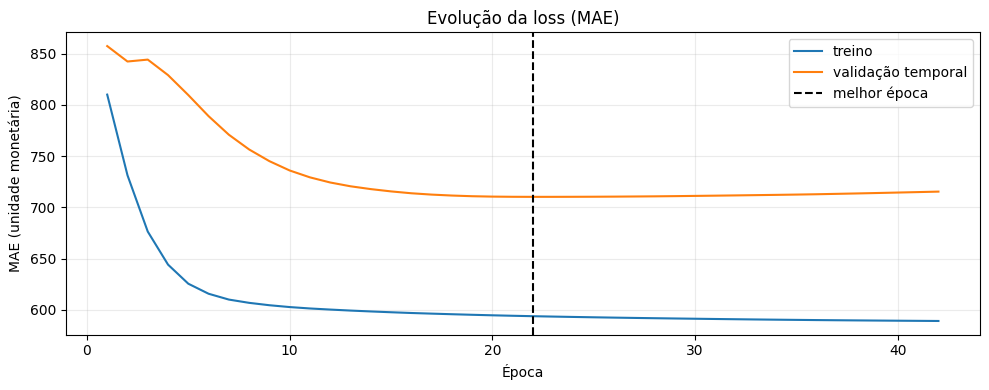

In [13]:
# Reajusta o modelo no treino completo e prevê o teste final.
def avaliar_previsoes(y, previsto, conjunto='teste'):
    residuo = (y - previsto).rename('residuo')
    mse = mean_squared_error(y, previsto)
    denominador = np.abs(y.to_numpy()) + np.abs(previsto.to_numpy())
    smape = np.mean(np.divide(
        2 * np.abs(y.to_numpy() - previsto.to_numpy()), denominador,
        out=np.zeros_like(denominador, dtype=float), where=denominador != 0
    )) * 100
    mape = (
        np.mean(np.abs((y.to_numpy() - previsto.to_numpy()) / y.to_numpy())) * 100
        if np.all(y.to_numpy() > 0) else np.nan
    )
    metricas = pd.DataFrame([{
        'conjunto': conjunto, 'n': len(y), 'MAE': mean_absolute_error(y, previsto),
        'MSE': mse, 'RMSE': mse ** 0.5, 'MAPE_percent': mape,
        'sMAPE_percent': smape, 'R2': r2_score(y, previsto),
        'vies_medio': residuo.mean(),
    }])
    return metricas, residuo

parametros_finais = {
    chave: melhor_configuracao[chave]
    for chave in ['hidden_layer_sizes', 'activation', 'solver', 'alpha']
}
regressor_mlp = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalonador', criar_escalonador(SCALER)),
    ('mlp', MLPRegressor(
        **parametros_finais, batch_size=BATCH_SIZE,
        max_iter=max(1, int(melhor_configuracao['melhor_epoca'])),
        early_stopping=False, shuffle=True, random_state=SEED,
    )),
])
modelo_mlp = TransformedTargetRegressor(
    regressor=regressor_mlp, transformer=StandardScaler()
)
inicio_avaliacao = time.perf_counter()
modelo_mlp.fit(X_train, y_train_delta)
previsao_treino = pd.Series(modelo_mlp.predict(X_train), index=y_train.index, name='previsao') + X_train['target_lag_1']
metricas_treino, residuos_treino = avaliar_previsoes(y_train, previsao_treino, 'treino')

previsao_mlp = pd.Series(modelo_mlp.predict(X_test), index=y_test.index, name='previsao') + X_test['target_lag_1']
metricas_mlp, residuos_mlp = avaliar_previsoes(y_test, previsao_mlp, 'teste_final')
tempo_avaliacao = time.perf_counter() - inicio_avaliacao
metricas_comparacao = pd.concat([metricas_treino, metricas_mlp], ignore_index=True)
display(metricas_comparacao.round(4))
if metricas_mlp['MAPE_percent'].isna().any():
    print('MAPE omitido porque o alvo contém zero ou valores negativos; use sMAPE.')
wf = pd.DataFrame({
    'modelo': 'MLP Regressor', 'origem': X_test.index,
    'ultima_observacao_disponivel': X_test.index - pd.tseries.frequencies.to_offset(FREQUENCY),
    'fim_intervalo_previsto': X_test.index + pd.tseries.frequencies.to_offset(FREQUENCY),
    'data': X_test.index, 'passo': HORIZON,
    'real': y_test.to_numpy(), 'previsto': previsao_mlp.to_numpy(),
    'residuo': residuos_mlp.to_numpy(),
    'persistencia': X_test['target_lag_1'].to_numpy(),
    'sazonal_periodo': X_test[f'target_lag_{SEASONAL_PERIOD}'].to_numpy(),
})
previsoes_mlp = wf.set_index('data')[['real', 'previsto', 'residuo']]
display(wf.head())

resumo_early_stopping = {
    'configuracao': melhor_nome,
    'epocas_executadas': len(historico_mlp),
    'melhor_epoca': int(melhor_configuracao['melhor_epoca']),
    'melhor_MAE_validacao': tabela_busca.loc[0, 'MAE_validacao'],
    'patience': PATIENCE,
    'tempo_busca_min': tempo_busca / 60,
    'tempo_avaliacao_min': tempo_avaliacao / 60,
}
display(pd.DataFrame([resumo_early_stopping]))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico_mlp['epoca'], historico_mlp['MAE_treino'], label='treino')
ax.plot(historico_mlp['epoca'], historico_mlp['MAE_validacao'], label='validação temporal')
ax.axvline(resumo_early_stopping['melhor_epoca'], color='black', linestyle='--', label='melhor época')
ax.set(title='Evolução da loss (MAE)', xlabel='Época', ylabel=f'MAE ({TARGET_UNIT})')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()



## Síntese técnica

- **Funcionamento:** aprende relações não lineares entre histórico, variáveis passadas e ciclos de calendário.
- **Saída:** um neurônio linear produz uma previsão contínua na unidade do alvo.
- **Vantagens:** flexibilidade, inferência rápida e interação entre diferentes features.
- **Limitações:** sensibilidade à escala e à inicialização, extrapolação fraca e menor interpretabilidade.

In [14]:
# Resume as propriedades e os resultados do modelo selecionado.
print('Arquitetura selecionada:', melhor_configuracao['hidden_layer_sizes'])
print(f'Saída linear para previsão contínua em {TARGET_UNIT}.')
print('O sklearn otimiza erro quadrático; arquitetura e época são selecionadas por MAE temporal.')
print(f'Early stopping: patience={PATIENCE}; o refit final usa a melhor época no treino completo.')
print('Teste: modelo congelado preve a variacao sobre o ultimo valor conhecido em cada origem.')
print('Limitações: sensibilidade à escala, extrapolação fraca e dependência dos lags observados.')
display(metricas_comparacao.round(4))

Arquitetura selecionada: (32,)
Saída linear para previsão contínua em unidade monetária.
O sklearn otimiza erro quadrático; arquitetura e época são selecionadas por MAE temporal.
Early stopping: patience=20; o refit final usa a melhor época no treino completo.
Teste: modelo congelado preve a variacao sobre o ultimo valor conhecido em cada origem.
Limitações: sensibilidade à escala, extrapolação fraca e dependência dos lags observados.


,conjunto,n,MAE,MSE,RMSE,MAPE_percent,sMAPE_percent,R2,vies_medio
0,treino,1934,612.9647,1.143647e+06,1069.4144,2.5160,2.4989,0.9963,-1.8546
1,teste_final,884,1401.8277,3.846214e+06,1961.1767,1.7114,1.7153,0.9893,160.4792


# 5. Avaliação


## Comparação com baselines

O resultado do MLP é comparado com referências simples:

- **persistência:** repete o último valor observado;
- **sazonal ingênuo:** repete o valor observado 7 dias antes.

Superar esses baselines confirma que a rede acrescenta informação além da continuidade e do ciclo semanal.

In [15]:
# Compara o MLP com os baselines no teste final.
def resumir_metricas(nome, real, previsto):
    erro = np.asarray(real) - np.asarray(previsto)
    return {
        'modelo': nome, 'n': len(erro),
        'MAE': float(np.abs(erro).mean()),
        'RMSE': float(np.sqrt(np.mean(erro ** 2))),
        'R2': float(r2_score(real, previsto)),
        'vies_real_menos_previsto': float(erro.mean()),
        'P90_erro_absoluto': float(np.quantile(np.abs(erro), 0.9)),
        'MaxAE': float(np.abs(erro).max()),
    }

metricas = pd.DataFrame([
    resumir_metricas('MLP Regressor', wf['real'], wf['previsto']),
    resumir_metricas(f'Persistência (1 {PERIOD_LABEL})', wf['real'], wf['persistencia']),
    resumir_metricas(f'Sazonal ingênuo ({SEASONAL_PERIOD} {PERIOD_LABEL_PLURAL})', wf['real'], wf['sazonal_periodo']),
])
mae_persistencia = metricas.loc[1, 'MAE']
metricas['ganho_MAE_vs_persistencia_pct'] = 100 * (1 - metricas['MAE'] / mae_persistencia)
display(metricas.round(4))
print(f'Busca: {tempo_busca / 60:.2f} min | treino e avaliação: {tempo_avaliacao / 60:.2f} min')
mensal = wf.set_index('data').resample('MS').apply({
    'residuo': lambda s: s.abs().mean(), 'real': 'count'
})
mensal.columns = ['MAE_MLP', 'n']
mensal['MAE_persistencia'] = (
    wf.set_index('data')['real'] - wf.set_index('data')['persistencia']
).abs().resample('MS').mean()


,modelo,n,MAE,RMSE,R2,vies_real_menos_previsto,P90_erro_absoluto,MaxAE,ganho_MAE_vs_persistencia_pct
0,MLP Regressor,884,1401.8277,1961.1767,0.9893,160.4792,3170.5807,9996.7563,-1.0719
1,Persistência (1 dia),884,1386.9603,1944.2168,0.9895,10.9076,3077.5071,10317.6021,0.0000
2,Sazonal ingênuo (7 dias),884,3725.7256,4964.8856,0.9314,64.2433,8340.4104,21859.4871,-168.6253


Busca: 0.12 min | treino e avaliação: 0.00 min


## Diagnóstico dos resíduos

- **Real vs. previsto:** mostra aderência e erros extremos.
- **Resíduo vs. previsto:** ajuda a identificar viés e variância não constante.
- **ACF:** revela dependências remanescentes entre os erros.
- **Ljung–Box:** testa estatisticamente a presença de autocorrelação.

> Um p-valor baixo indica que ainda existe estrutura temporal não capturada pelo modelo.


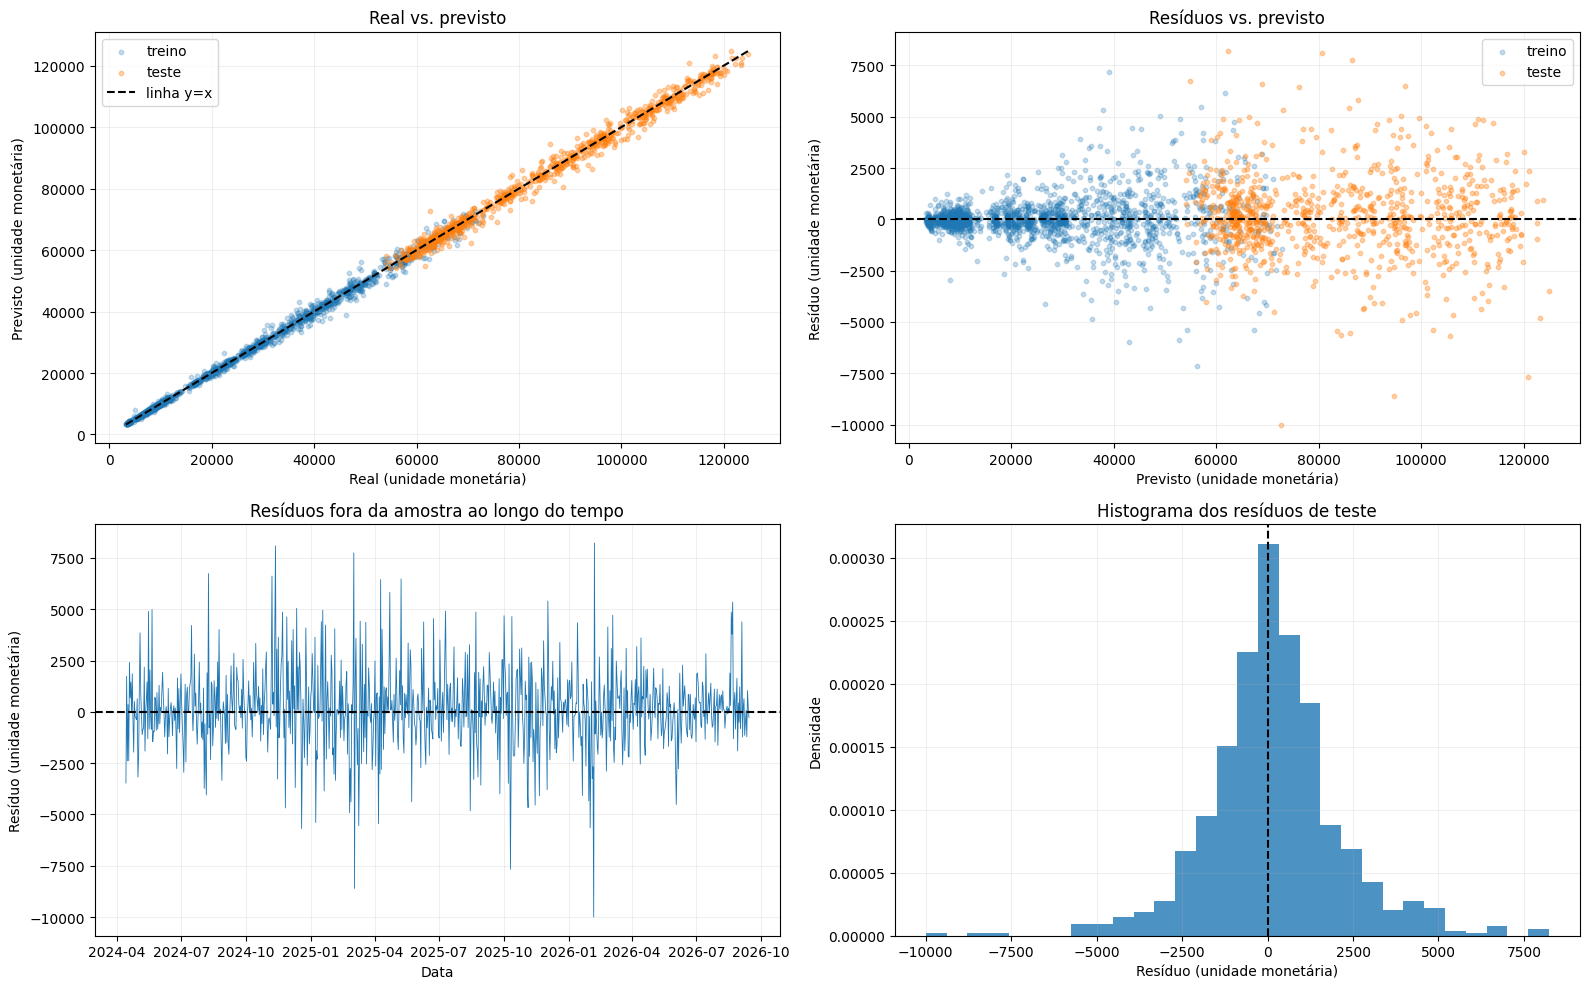

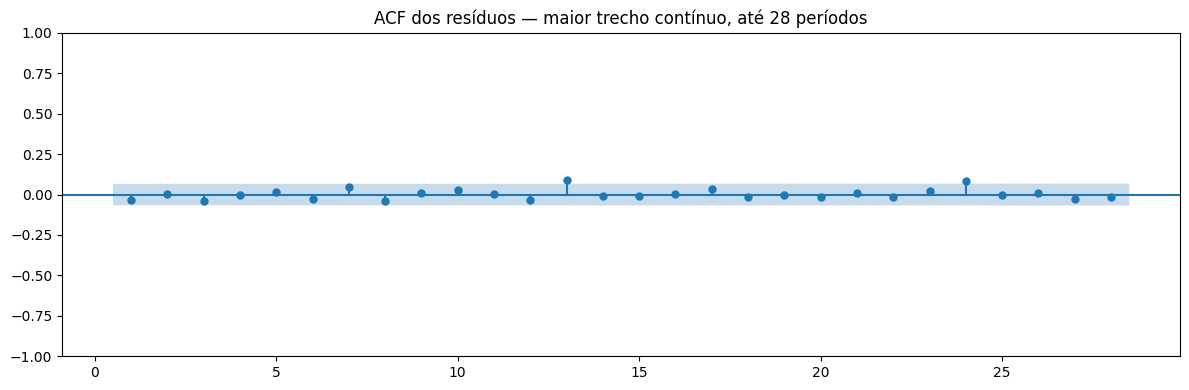

,lb_stat,lb_pvalue
lag_periodos,,
1,0.921654,0.337041
2,0.929622,0.628254
3,2.514782,0.472626
7,5.492686,0.600066
14,15.732262,0.329997
28,25.631542,0.593290


Não há evidência de autocorrelação residual nos lags avaliados (p >= 0,05).


In [16]:
# Diagnostica os resíduos fora da amostra.
residuos_mlp = wf.set_index('data')['residuo'].sort_index()
residuos_continuos = maior_trecho_continuo(residuos_mlp)
amostra_treino = previsao_treino.sample(
    n=min(5000, len(previsao_treino)), random_state=SEED
).index
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

axes[0].scatter(y_train.loc[amostra_treino], previsao_treino.loc[amostra_treino], alpha=0.25, s=10, label='treino')
axes[0].scatter(y_test, previsao_mlp, alpha=0.35, s=10, label='teste')
mn = min(y_train.min(), y_test.min(), previsao_treino.min(), previsao_mlp.min())
mx = max(y_train.max(), y_test.max(), previsao_treino.max(), previsao_mlp.max())
axes[0].plot([mn, mx], [mn, mx], '--', color='black', label='linha y=x')
axes[0].set(title='Real vs. previsto', xlabel=f'Real ({TARGET_UNIT})', ylabel=f'Previsto ({TARGET_UNIT})')
axes[0].legend()

axes[1].scatter(previsao_treino.loc[amostra_treino], residuos_treino.loc[amostra_treino], alpha=0.25, s=10, label='treino')
axes[1].scatter(previsao_mlp, residuos_mlp, alpha=0.35, s=10, label='teste')
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set(title='Resíduos vs. previsto', xlabel=f'Previsto ({TARGET_UNIT})', ylabel=f'Resíduo ({TARGET_UNIT})')
axes[1].legend()

axes[2].plot(residuos_mlp.index, residuos_mlp, linewidth=0.6)
axes[2].axhline(0, linestyle='--', color='black')
axes[2].set(title='Resíduos fora da amostra ao longo do tempo', xlabel='Data', ylabel=f'Resíduo ({TARGET_UNIT})')

axes[3].hist(residuos_mlp, bins=30, density=True, alpha=0.8)
axes[3].axvline(0, linestyle='--', color='black')
axes[3].set(title='Histograma dos resíduos de teste', xlabel=f'Resíduo ({TARGET_UNIT})', ylabel='Densidade')
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

acf_lag = min(MAX_ACF_LAG, len(residuos_continuos) - 1)
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(residuos_continuos, lags=acf_lag, zero=False, ax=ax)
ax.set_title(f'ACF dos resíduos — maior trecho contínuo, até {acf_lag} períodos')
plt.tight_layout(); plt.show()

lags_validos = [lag for lag in LJUNG_LAGS if lag < len(residuos_continuos)]
ljung_box_mlp = acorr_ljungbox(residuos_continuos, lags=lags_validos, return_df=True)
ljung_box_mlp.index.name = 'lag_periodos'
display(ljung_box_mlp)
if (ljung_box_mlp['lb_pvalue'] < 0.05).any():
    print('Há evidência de autocorrelação residual (p < 0,05); ainda resta estrutura temporal não capturada.')
else:
    print('Não há evidência de autocorrelação residual nos lags avaliados (p >= 0,05).')


## Importância das features

A importância por permutação embaralha uma feature por vez e mede o aumento do MAE:

- aumento maior significa maior contribuição preditiva;
- valores próximos de zero indicam pouca contribuição isolada;
- features correlacionadas podem dividir importância entre si.

O método melhora a interpretação sem alterar o modelo treinado.


,feature,importancia,desvio_importancia,metodo,coeficiente,p_valor
0,target_roll_mean_7,60.0535,2.6250,permutacao,NaN,NaN
1,target_lag_1,54.1515,1.8644,permutacao,NaN,NaN
2,priceHigh_lag_7,47.0760,1.4003,permutacao,NaN,NaN
3,target_lag_7,42.1291,1.5907,permutacao,NaN,NaN
4,target_lag_2,32.2165,2.3241,permutacao,NaN,NaN
5,volume_lag_7,29.1512,1.9225,permutacao,NaN,NaN
6,target_lag_14,28.3617,1.6139,permutacao,NaN,NaN
7,target_roll_mean_28,28.2577,1.2903,permutacao,NaN,NaN
8,target_lag_28,21.8616,1.0301,permutacao,NaN,NaN
9,target_roll_std_7,18.0866,2.4361,permutacao,NaN,NaN


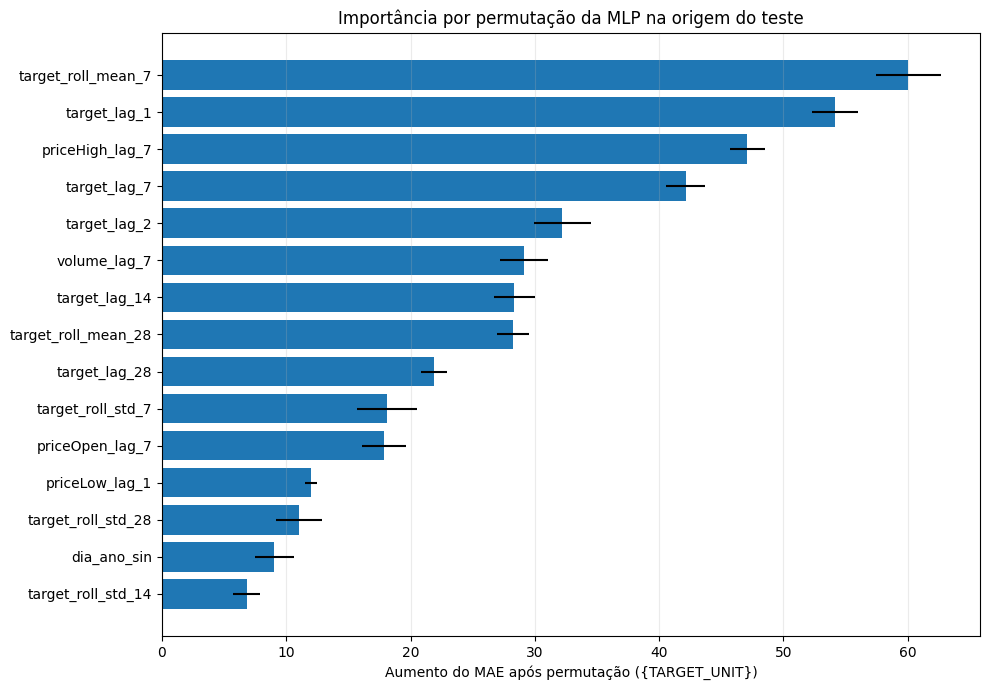

Principais features: target_roll_mean_7, target_lag_1, priceHigh_lag_7, target_lag_7, target_lag_2
A importância mede o aumento do MAE ao embaralhar cada feature; valores maiores indicam maior contribuição preditiva.


,feature,importancia,desvio_importancia,metodo,coeficiente,p_valor
2,priceHigh_lag_7,47.0760,1.4003,permutacao,NaN,NaN
5,volume_lag_7,29.1512,1.9225,permutacao,NaN,NaN
10,priceOpen_lag_7,17.8699,1.7755,permutacao,NaN,NaN
11,priceLow_lag_1,11.9651,0.4816,permutacao,NaN,NaN
15,priceHigh_lag_1,4.1134,1.0672,permutacao,NaN,NaN
19,priceOpen_lag_1,-1.8147,2.4106,permutacao,NaN,NaN
21,volume_lag_1,-5.8077,1.3729,permutacao,NaN,NaN
22,priceLow_lag_7,-10.2799,1.4995,permutacao,NaN,NaN


As entradas usam somente medições passadas ou indicadores conhecidos antecipadamente.


In [17]:
# Estima a importância das features por permutação.
importancias_mlp = calcular_importancia_features(
    modelo_mlp, X_test, y_test, metodo='permutacao',
    n_repeticoes=10, seed=SEED, n_jobs=-1, max_amostras=3000,
)
display(importancias_mlp.head(15).round(4))
top = importancias_mlp.head(15).sort_values('importancia')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top['feature'], top['importancia'], xerr=top['desvio_importancia'])
ax.set_title('Importância por permutação da MLP na origem do teste')
ax.set_xlabel('Aumento do MAE após permutação ({TARGET_UNIT})')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout(); plt.show()
print('Principais features:', ', '.join(importancias_mlp.head(5)['feature']))
print('A importância mede o aumento do MAE ao embaralhar cada feature; valores maiores indicam maior contribuição preditiva.')
prefixos_exogenas = tuple([*EXOG_COLUMNS, *KNOWN_INDICATORS])
importancias_exogenas = importancias_mlp[
    importancias_mlp['feature'].str.startswith(prefixos_exogenas)
].head(10)
display(importancias_exogenas.round(4))
print('As entradas usam somente medições passadas ou indicadores conhecidos antecipadamente.')
